In [9]:
import virtualizarr
import fsspec
from datetime import datetime
import xarray as xr

In [10]:
def create_query(date, band='C01'):
    """
    Creates a query for listing GOES16 files stored in AWS bucket
    :param date: date to be queried. e.g datetime(2021, 10, 3, 12). Datetime python object
    :param band: Goes16 band to be queried e.g. C01
    :return: string with a
    """
    prefix = f'ABI-L1b-RadF/{date:%Y}/{date.timetuple().tm_yday:03d}/{date:%H}/OR_ABI-L1b-RadF-M6{band}_G19_s' \
             f'{date:%Y}{date.timetuple().tm_yday:03d}*'
    return prefix

def download_s3file(s3_path: str)-> str:
    return fsspec.open_local(
            f"simplecache::s3://{s3_path}",
            s3={"anon": True},
            filecache={"cache_storage": "."},
        )


In [11]:
fs = fsspec.filesystem("s3", anon=True)

In [12]:
dt = datetime(2025, 4, 2, 13, 10, 4)  # Match your original timestamp
query = create_query(dt, band="C13")
query

'ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s2025092*'

In [13]:
goes_files =  ['s3://' + f for f in
              # sorted(fs.glob(f"s3://noaa-goes19/ABI-L1b-RadF/2025/092/13/*"))
              sorted(fs.glob(f"s3://noaa-goes19/{query}"))
             ]

In [14]:
goes_files

['s3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921300198_e20250921309518_c20250921309563.nc',
 's3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921310198_e20250921319518_c20250921319543.nc',
 's3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921320198_e20250921329517_c20250921329546.nc',
 's3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921330198_e20250921339517_c20250921339553.nc',
 's3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921340198_e20250921349518_c20250921349556.nc',
 's3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921350198_e20250921359517_c20250921359553.nc']

In [17]:
so = dict(anon=True, default_fill_cache=False, default_cache_type="none")

In [18]:
ds_vir = virtualizarr.open_virtual_dataset(goes_files[0], 
                                           indexes={}, 
                                           reader_options={"storage_options": so})

In [19]:
ds_vir.virtualize.to_kerchunk("data/single_file_kerchunk.json", format="json")

In [22]:
# We once again need to provide information for fsspec to access the remote file
storage_options = dict(
    remote_protocol="s3", remote_options=dict(anon=True)
)
# We will use the "kerchunk" engine in `xr.open_dataset` and pass the `storage_options` to the `kerchunk` engine through `backend_kwargs`
ds = xr.open_dataset(
    "data/single_file_kerchunk.json",
    engine="kerchunk",
    backend_kwargs={"storage_options": storage_options},
)
ds

<xarray.Dataset> Size: 353MB
Dimensions:                                           (y: 5424, x: 5424,
                                                       number_of_time_bounds: 2,
                                                       number_of_image_bounds: 2,
                                                       number_of_harmonization_coefficients: 3,
                                                       num_star_looks: 24,
                                                       band: 1)
Coordinates:
    t                                                 datetime64[ns] 8B ...
  * y                                                 (y) float64 43kB 0.1518...
  * x                                                 (x) float64 43kB -0.151...
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
    band_id                                           (band) float32 4B ...
    band_wavelength                                   (band) float32 4B ...
  * number_of_harmonization_coefficients              (number_of_harmonization_coefficients) float64 24B ...
  * num_star_looks                                    (num_star_looks) float64 192B ...
    t_star_look                                       (num_star_looks) datetime64[ns] 192B ...
    band_wavelength_star_look                         (num_star_looks) float32 96B ...
Dimensions without coordinates: number_of_time_bounds, number_of_image_bounds,
                                band
Data variables: (12/39)
    Rad                                               (y, x) float64 235MB ...
    DQF                                               (y, x) float32 118MB ...
    time_bounds                                       (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                            float64 8B ...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    ...                                                ...
    algorithm_dynamic_input_data_container            float64 8B ...
    processing_parm_version_container                 float64 8B ...
    algorithm_product_version_container               float64 8B ...
    star_id                                           (num_star_looks) float32 96B ...
    channel_integration_time                          float64 8B ...
    channel_gain_field                                float64 8B ...
Attributes: (12/30)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           WCDAS
    ...                        ...
    timeline_id:               ABI Mode 6
    date_created:              2025-04-02T13:09:56.3Z
    time_coverage_start:       2025-04-02T13:00:19.8Z
    time_coverage_end:         2025-04-02T13:09:51.8Z
    LUT_Filenames:             SpaceLookParams(FM4A_CDRL79RevA_DO_14_00_00)-7...
    id:                        002913e3-2223-4016-8d41-814efbee314f

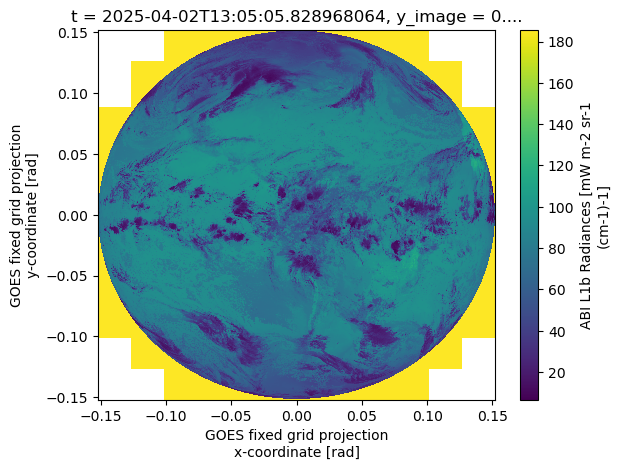

In [23]:
ds.Rad.plot()